<a href="https://colab.research.google.com/github/ElicodeGML/script_python/blob/main/IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nouvelle section AUTRE

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Chargement des images en couleur (Avions, Bateaux, Voitures...)
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# Normalisation des pixels (entre 0 et 1)
X_train, X_test = X_train / 255.0, X_test / 255.0

# Noms des classes dans le dataset
nom_classes = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']

# 2. Construction du Réseau de Neurones Convolutif (CNN)
model = models.Sequential()

# Première couche de convolution : repère les lignes et les bords simples
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2))) # Réduit la taille pour garder l'essentiel

# Deuxième couche : combine les lignes pour repérer des formes plus complexes
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Troisième couche de convolution
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# 3. Passage aux couches d'analyse (Classification)
model.add(layers.Flatten()) # On aplatit les formes trouvées
model.add(layers.Dense(64, activation='relu')) # Couche de réflexion
model.add(layers.Dense(10)) # 10 sorties pour nos 10 catégories d'objets

# Affichage de l'architecture du réseau
model.summary()

# 4. Compilation du moteur de l'IA
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 5. Entraînement (On commence par 10 époques pour voir)
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test))


  5644288/170498071 ━━━━━━━━━━━━━━━━━━━━ 28:51 11us/step

KeyboardInterrupt: 

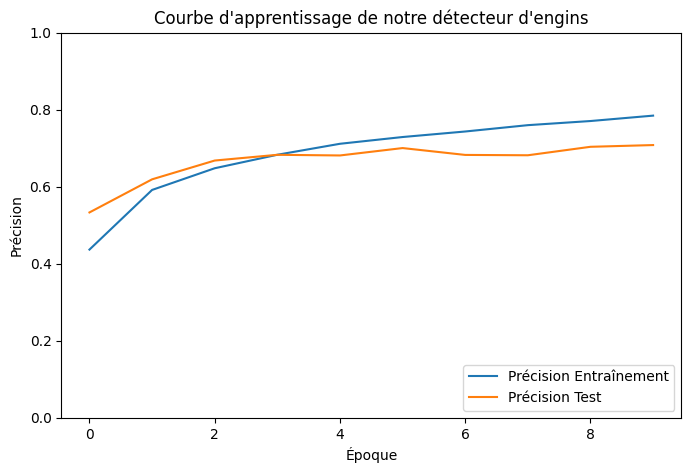

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Précision Entraînement')
plt.plot(history.history['val_accuracy'], label = 'Précision Test')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title("Courbe d'apprentissage de notre détecteur d'engins")
plt.show()

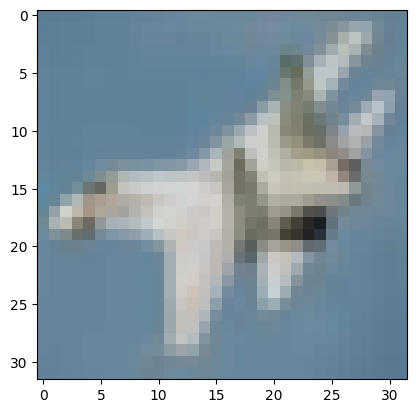

avion
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
cerf


In [ ]:
import random
x = random.randint(0, 100)
plt.imshow(X_test[x])
plt.show()
print(nom_classes[y_test[x][0]])

image_prete = tf.expand_dims(X_test[x], 0)
prediction = model.predict(image_prete)

print(nom_classes[prediction.argmax()])

# Nouvelle sectionYOLO

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model_yolo = YOLO('yolov8n.pt')
result = model_yolo('chat.jpg', save=True, conf=0.46)



image 1/1 /content/chat.jpg: 416x640 6 cats, 329.9ms
Speed: 10.0ms preprocess, 329.9ms inference, 38.4ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


In [ ]:
from ultralytics import YOLO

model_yolo = YOLO('yolov8n.pt')

# On plonge directement dans la structure brute du réseau pytorch sous-jacent
print(model_yolo.se)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

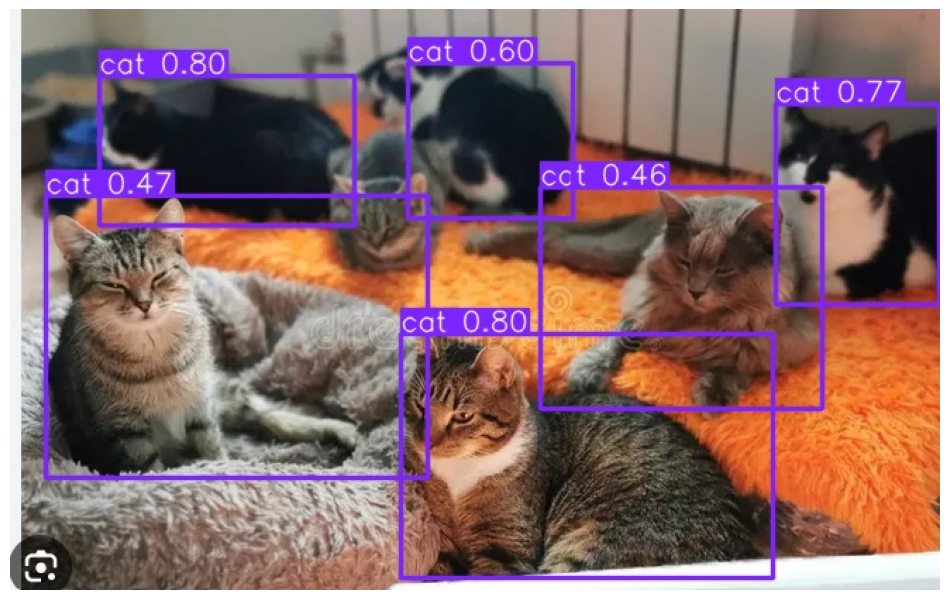

In [ ]:
import cv2
import matplotlib.pyplot as plt

# On va chercher l'image là où YOLO l'a enregistrée
# Attention : vérifie bien si c'est "aeroprt.jpg" ou un autre nom dans ton dossier
image_detectee = cv2.imread('/content/runs/detect/predict/chat.jpg')
image_detectee = cv2.cvtColor(image_detectee, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_detectee)
plt.axis('off')
plt.show()

# Nouvelle section MON_IA

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class MonReseauIndustriel(nn.Module):
    def __init__(self, num_classes=10):
        super(MonReseauIndustriel, self).__init__()

        # BLOC 1 : Extraction des premiers détails (3 canaux couleur -> 32 filtres)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # Stabilisateur mathématique
        self.act1 = nn.SiLU()         # L'interrupteur moderne (comme YOLO)

        # BLOC 2 : Approfondissement (32 -> 64 filtres)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.act2 = nn.SiLU()

        # Réducteur de taille (Pooling)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # BLOC 3 : Décision finale (Classification)
        self.flatten = nn.Flatten()
        # Si notre image fait 32x32 au départ, après un MaxPool elle fait 16x16.
        # 16 * 16 * 64 filtres = 16384 connexions
        self.fc1 = nn.Linear(16384, 128)
        self.fc2 = nn.Linear(128, num_classes) # Sortie (ex: 10 classes)

    def forward(self, x):
        # Passage dans le Bloc 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)

        # Passage dans le Bloc 2 + Réduction
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.pool(x)

        # Aplatissement et Décision
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# 1. Création de l'instance du modèle
mon_ia = MonReseauIndustriel(num_classes=10)

# 2. La fonction de perte (CrossEntropy)
critere = nn.CrossEntropyLoss()

# 3. L'optimiseur (Adam) à qui on donne les paramètres de notre classe à modifier
optimiseur = optim.Adam(mon_ia.parameters(), lr=0.001)

print(mon_ia)

MonReseauIndustriel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): SiLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): SiLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Creating a Small, Synthetic Dataset

Since you requested a small dataset, I'm generating a synthetic one using `numpy`. This will quickly provide `X_train`, `y_train`, `X_test`, and `y_test` with shapes similar to the CIFAR-10 dataset, but with a much smaller number of samples for faster experimentation.

In [ ]:
import numpy as np

# Define parameters for the synthetic dataset
num_train_samples = 100  # A very small number of training images
num_test_samples = 20    # A very small number of testing images
image_size = 32
num_channels = 3
num_classes = 10

print("Generating a small synthetic dataset...")

# Create synthetic training data
# Images are random floats between 0 and 1, simulating normalized pixel values
X_train = np.random.rand(num_train_samples, image_size, image_size, num_channels).astype(np.float32)
# Labels are random integers from 0 to num_classes-1
y_train = np.random.randint(0, num_classes, (num_train_samples, 1)).astype(np.int64)

# Create synthetic testing data
X_test = np.random.rand(num_test_samples, image_size, image_size, num_channels).astype(np.float32)
y_test = np.random.randint(0, num_classes, (num_test_samples, 1)).astype(np.int64)

print(f"Synthetic X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Synthetic X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("Synthetic dataset created successfully. You can now proceed to run the PyTorch data preparation and training cells.")

Generating a small synthetic dataset...
Synthetic X_train shape: (100, 32, 32, 3), y_train shape: (100, 1)
Synthetic X_test shape: (20, 32, 32, 3), y_test shape: (20, 1)
Synthetic dataset created successfully. You can now proceed to run the PyTorch data preparation and training cells.


In [ ]:
# Exemple théorique de ce qui se passe dans une boucle d'entraînement :
def entrainer_une_epoque(modele, donnees_images, vraies_etiquettes):
    # 1. Remettre les compteurs de correction à zéro
    optimiseur.zero_grad()

    # 2. Le "Forward" : L'IA tente de deviner les images
    predictions = modele(donnees_images)

    # 3. Le calcul de l'erreur
    loss = critere(predictions, vraies_etiquettes)

    # 4. Le "Backward" (Rétropropagation) : Le calcul mathématique de l'erreur
    # pour chaque neurone, du fond du réseau jusqu'au début.
    loss.backward()

    # 5. La mise à jour : On ajuste légèrement les filtres
    optimiseur.step()

    return loss.item()


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convertir les données de NumPy en tenseurs PyTorch
X_train_torch = torch.tensor(X_train).permute(0, 3, 1, 2).float() # (N, H, W, C) -> (N, C, H, W) et float
y_train_torch = torch.tensor(y_train).long().squeeze() # Long pour CrossEntropyLoss, enlever la dimension superflue
X_test_torch = torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_test_torch = torch.tensor(y_test).long().squeeze()

# Créer des datasets et dataloaders
train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Données converties en tenseurs PyTorch et DataLoaders créés.")

Données converties en tenseurs PyTorch et DataLoaders créés.


Maintenant, nous allons entraîner le modèle sur ces données.

In [ ]:
num_epochs = 10 # Vous pouvez ajuster le nombre d'époques

for epoch in range(num_epochs):
    mon_ia.train() # Mettre le modèle en mode entraînement
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        optimiseur.zero_grad()
        outputs = mon_ia(inputs)
        loss = critere(outputs, labels)
        loss.backward()
        optimiseur.step()
        running_loss += loss.item()

    # Évaluation après chaque époque
    mon_ia.eval() # Mettre le modèle en mode évaluation
    correct = 0
    total = 0
    with torch.no_grad(): # Désactiver le calcul des gradients pour l'évaluation
        for inputs, labels in test_loader:
            outputs = mon_ia(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Époque [{epoch+1}/{num_epochs}], Perte: {running_loss/len(train_loader):.4f}, Précision Test: {accuracy:.2f}%')

print('\nEntraînement terminé !')

Époque [1/10], Perte: 7.2187, Précision Test: 5.00%
Époque [2/10], Perte: 7.2762, Précision Test: 0.00%
Époque [3/10], Perte: 5.8357, Précision Test: 10.00%
Époque [4/10], Perte: 3.9944, Précision Test: 30.00%
Époque [5/10], Perte: 3.3660, Précision Test: 25.00%
Époque [6/10], Perte: 2.9742, Précision Test: 5.00%
Époque [7/10], Perte: 2.4137, Précision Test: 10.00%
Époque [8/10], Perte: 1.9300, Précision Test: 20.00%
Époque [9/10], Perte: 1.6040, Précision Test: 15.00%
Époque [10/10], Perte: 1.4009, Précision Test: 15.00%

Entraînement terminé !
